In [1]:
import random
import numpy as np


# non_pareto_points = []
# for _ in range(4):
#     new_point = (random.randint(4, 7), random.randint(3, 5), random.randint(2, 3))
#     non_pareto_points.append(new_point)
# non_pareto_points = np.unique(points, axis=0)

pareto_points = np.array([(6,3,1),(5,3,2),(4,4,3)])
non_pareto_points = np.array([(6,4,3),(6,3,2),(5,4,3),])




[array([[7. , 4.5, 1. ],
       [7. , 3. , 1. ],
       [6. , 3. , 1. ]]), array([[5. , 3. , 2. ],
       [4. , 4. , 3. ],
       [7. , 4.5, 3.5]]), array([[5. , 3. , 2. ],
       [7. , 4.5, 3.5],
       [7. , 4.5, 1. ]]), array([[6. , 3. , 1. ],
       [5. , 3. , 2. ],
       [7. , 4.5, 1. ]]), array([[7. , 4.5, 3.5],
       [4. , 4. , 3. ],
       [4. , 4.5, 3.5]])]


/scratch/lsftmp/13427430.tmpdir/ipykernel_56287/3737840334.py:106: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  ax.w_xaxis.set_pane_color(light_grey)  # X-axis pane
/scratch/lsftmp/13427430.tmpdir/ipykernel_56287/3737840334.py:107: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  ax.w_yaxis.set_pane_color(light_grey)  # Y-axis pane
/scratch/lsftmp/13427430.tmpdir/ipykernel_56287/3737840334.py:108: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  ax.w_zaxis.set_pane_color(light_grey)  # Z-axis pane
/scratch/lsftmp/13427430.tmpdir/ipykernel_56287/3737840334.py:113: MatplotlibDeprecationWarning: The dist attribute was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax.dist = 13


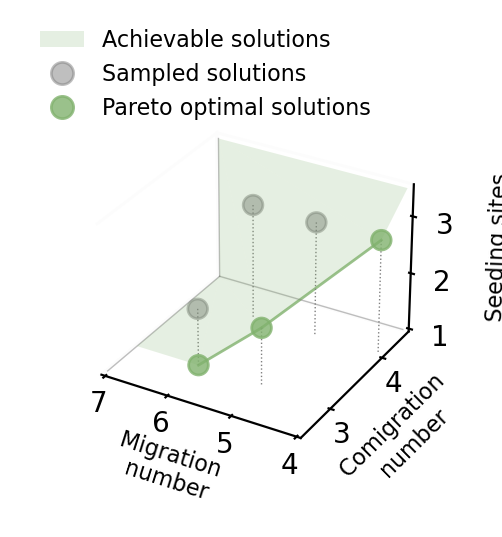

In [10]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import matplotlib.patches as patches
from matplotlib.lines import Line2D 

fig = plt.figure(figsize=(4,3),dpi=200)
ax = fig.add_subplot(111, projection='3d')

    
# Draw lines connecting Pareto points
for i in range(len(pareto_points)-1):
    ax.plot([pareto_points[i,0], pareto_points[i+1,0]], 
            [pareto_points[i,1], pareto_points[i+1,1]], 
            [pareto_points[i,2], pareto_points[i+1,2]], 
            color='#81b26e', linewidth=1, alpha=0.8)

# vertices = np.array([[3,3,2], [4,3,1], [4,3,1], [3,3,1]])

# # Create triangles to form the shaded surface
# triangles = [[0,1,2], [0,2,3]]

# # Create the shaded surface using plot_trisurf
# ax.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], 
#                 triangles=triangles,
#                 color='#90EE90',  # Using a brighter green
#                 alpha=0.2)  # Slightly increased opacity

# # Add lines connecting the points
# ax.plot([vertices[0,0], vertices[1,0]], 
#         [vertices[0,1], vertices[1,1]], 
#         [vertices[0,2], vertices[1,2]], 
#         color='#81b26e', linewidth=1)

#ax.scatter(min_mig_points[:, 0], min_mig_points[:, 1], min_mig_points[:, 2], label='Other methods', color='red', alpha=1.0,s=50)

ax.set_xlabel('Migration \nnumber',fontsize=8, labelpad=0)
ax.set_ylabel('Comigration \nnumber',fontsize=8, labelpad=0)
ax.set_zlabel('Seeding sites',fontsize=8, labelpad=4)
# Remove grey background and grid
ax.set_facecolor('white')

# Adjusting plot limits to prevent clipping
x_low_lim, x_up_lim = 4, 7
y_low_lim, y_up_lim = 2.5, 4.5
z_low_lim, z_up_lim = 1, 3.5
ax.set_xlim([x_up_lim,x_low_lim])
ax.set_ylim([y_low_lim, y_up_lim])
ax.set_zlim([z_low_lim, z_up_lim])
ax.set_xticks(range(7,3,-1))
ax.set_yticks(range(3, 5))
ax.set_zticks(range(1, 4))

for points in [pareto_points, non_pareto_points]:
    for point in points:
            ax.plot([point[0], point[0]], [point[1], point[1]], [point[2], z_low_lim], 
                    color='grey', linestyle='dotted', linewidth=0.5)

# Fix syntax error in boundary array definition
boundary1 = np.array([
    [x_up_lim, y_up_lim, z_low_lim],
    [x_up_lim, pareto_points[0][1], z_low_lim], 
    pareto_points[0]
])
boundary2 = np.array([
    pareto_points[1],
    pareto_points[2],
    [x_up_lim,y_up_lim, z_up_lim],
])
boundary3 = np.array([
    pareto_points[1],
    [x_up_lim,y_up_lim, z_up_lim],
    [x_up_lim,y_up_lim, z_low_lim],
])
boundary4 = np.array([
    pareto_points[0],
    pareto_points[1],
    [x_up_lim,y_up_lim, z_low_lim],
])
boundary5 = np.array([
    [x_up_lim,y_up_lim, z_up_lim],
    pareto_points[2],
    [x_low_lim,y_up_lim, z_up_lim],
])

# Combine boundary with pareto points
all_points = [boundary1,boundary2,boundary3,boundary4,boundary5]

print(all_points)
poly = Poly3DCollection(all_points, alpha=0.2, facecolor='#81b26e')
ax.add_collection3d(poly)

ax.tick_params(axis='x', pad=-3)  # Adjusts padding for x-axis ticks
ax.tick_params(axis='y', pad=-3)  # Adjusts padding for y-axis ticks
ax.tick_params(axis='z', pad=1)  # Adjusts padding for z-axis ticks

# Scatter all points
ax.scatter(non_pareto_points[:, 0], non_pareto_points[:, 1], non_pareto_points[:, 2], label='Sampled solutions', color='grey', alpha=0.5, s=50)

# Highlight the Pareto front
ax.scatter(pareto_points[:, 0], pareto_points[:, 1], pareto_points[:, 2], label='Pareto optimal solutions', color='#81b26e', alpha=0.8,s=50)

light_grey = (0.99, 0.99, 0.99, 1.0)

ax.w_xaxis.set_pane_color(light_grey)  # X-axis pane
ax.w_yaxis.set_pane_color(light_grey)  # Y-axis pane
ax.w_zaxis.set_pane_color(light_grey)  # Z-axis pane

# Set the figure background color to white
fig.patch.set_facecolor('white')
ax.view_init(30,)  # Change the elevation and azimuth here
ax.dist = 13

# Create separate legend entries for each element
legend_elements = [
    patches.Rectangle((0,0), 1, 1, facecolor='#81b26e', alpha=0.2), # For the poly surface
    Line2D([0], [0], marker='o', color='grey', label='Sampled solutions', 
           markerfacecolor='grey', markersize=8, alpha=0.5, linestyle='None'),
    Line2D([0], [0], marker='o', color='#81b26e', label='Pareto optimal solutions',
           markerfacecolor='#81b26e', markersize=8, alpha=0.8, linestyle='None')
]

ax.legend(legend_elements, ['Achievable solutions', 'Sampled solutions', 'Pareto optimal solutions'],
          frameon=False, fontsize=8, loc='upper left', bbox_to_anchor=(0, 1.1))


# Turn off all grid lines
ax.grid(False)

# Turn off panes (the grey background planes)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False


# Add lines connecting the planes at their intersections
ax.plot([x_up_lim, x_up_lim], [y_low_lim, y_up_lim], [z_low_lim, z_low_lim], color='grey', linewidth=0.5, alpha=0.5)  # Bottom edge
ax.plot([x_up_lim, x_low_lim], [y_up_lim, y_up_lim], [z_low_lim, z_low_lim], color='grey', linewidth=0.5, alpha=0.5)  # Bottom edge
ax.plot([x_up_lim, x_up_lim], [y_up_lim, y_up_lim], [z_low_lim, z_up_lim], color='grey', linewidth=0.5, alpha=0.5)  # Vertical edge

plt.savefig('/data/morrisq/divyak/projects/metient/metient/jupyter_notebooks/random/outputs/pareto_viz.svg', dpi=300, pad_inches=0.1)  # Save as a PNG file with high resolution
plt.show()


In [95]:
all_points


[array([[7. , 4. , 1. ],
        [7. , 1.5, 1. ],
        [7. , 1.5, 3.5],
        [3.5, 1.5, 3.5]]),
 array([[6, 3, 1],
        [5, 3, 2],
        [4, 4, 3]])]

In [ ]:


# # Example data points representing a Pareto front
# np.random.seed(0)

# # Filter for Pareto front (assuming minimization)
# def is_pareto_efficient(points):
#     """ 
#     Args:
#         - solutions: list of VertexLabelingSolutions of length n
#         - all_pars_metrics: list of tuples with parsimony mentrics
#         for (migration #, comigration #, seeding site #) of length n

#     """
    
#     # Start with an empty Pareto front
#     is_efficient = np.zeros(len(points), dtype=bool)
#     pareto_front = []
#     # Loop through each solution in the list
#     for i,point in enumerate(points):
#         # Assume candidate is not dominated; check against all others
#         if not any(all(other[0][i] <= point[i] for i in range(len(point))) and
#                    any(other[0][i] < point[i] for i in range(len(point))) 
#                    for other in pareto_front):
#             # If no one in the current Pareto front dominates the candidate, add it
#             pareto_front.append((list(point),i))
#             # Remove any from the pareto_front that is dominated by the new candidate
#             pareto_front = [front for front in pareto_front if not all(point[i] <= front[0][i] for i in range(len(point))) or not any(point[i] < front[0][i] for i in range(len(point)))]
    
#     for point in pareto_front:
#         is_efficient[point[1]] = 1
#     print("pareto_front", set([(x[0][0], x[0][1], x[0][2]) for x in pareto_front]))
#     return is_efficient

# def is_min_mig_number(points):
#     """ 
#     Args:
#         - solutions: list of VertexLabelingSolutions of length n
#         - all_pars_metrics: list of tuples with parsimony mentrics
#         for (migration #, comigration #, seeding site #) of length n

#     Returns:
#         - a list of solutions with lowest migration number
#     """
    
#     # Start with an empty Pareto front
#     has_lowest_mig_num = np.zeros(len(points), dtype=bool)
#     min_mig_num = float("inf")
#     for i,point in enumerate(points):
        
#         if point[0] < min_mig_num:
#             min_mig_num = point[0]
#     print("min_mig_num", min_mig_num)
    
#     for i,point in enumerate(points):
        
#         if point[0] == min_mig_num:
#             has_lowest_mig_num[i] = 1
#     return has_lowest_mig_num


# # pareto_points = points[is_pareto_efficient(points)]
# # non_pareto_points = points[~is_pareto_efficient(points)]
# # print(pareto_points)
# # min_mig_points = points[is_pareto_efficient(points)&is_min_mig_number(points)]